# No surprises

<style>
.MathJax {
  font-family: "Common HTML";
}
</style>

$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\operatornamewithlimits{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
\newcommand{\loss}{\ell}
\newcommand{\eloss}{\mc{L}}
\newcommand{\abs}[1]{| #1 |}
\newcommand{\norm}[1]{\| #1 \|}
\newcommand{\tp}{T}
$$

__<div style="text-align: right"> ASE3001: Computational Experiments for Aerospace Engineering, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_
_<div style="text-align: right"> Jiwoo Choi (jiwoochoi@inha.edu) </div>_

<br>

___

<br>

In this section, we will load a sound sample (`.wav` file), and examine which musical notes (or chords) the song consists of. For your information, the frequency-note matching table can be found via Googling, for example from, https://en.wikipedia.org/wiki/Piano_key_frequencies.

<br>

We will first need to import the following modules, the third for loading `.wav` file, and the last for playing it.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

<br>

In this lecture, we will access data files which are uploaded on the Google drive. In order to do this, we will have to mount the Goodle drive first.

1) Run the following cell. Then you will be presented with a link and will be asked to enter your authorization code.

2) Click on the link to log in again with your Inha University account, which you are working with. Then you will be presented with the authorization code.

3) Copy the authorization code, and paste it into the blank.

> _Note that this step is necessary ONLY when you work on Google Colab environment._

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Colab Notebooks/ase3001')

ModuleNotFoundError: No module named 'google.colab'

The following pieces of code loads the first 12 second sound clip of a song that you've probably heard of.
The loaded data contains the sampling rate, `data[0]`, and the time-series signals from stereo channels, `data[1]`.

In [3]:
# The wave file can be downloaded from
# https://jonghank.github.io/ase3001/files/no_surprises_clip.wav

data = wavfile.read(r'C:\Users\변정우\OneDrive\Desktop\3학년\수치해석 프로젝트\5주차 과제\no_surprises_clip.wav')
#data = wavfile.read('/content/drive/MyDrive/Colab Notebooks/ase3001/no_surprises_clip.wav')framerate = data[0]
sounddata = data[1]
t = np.arange(0,len(sounddata))/framerate

plt.figure(figsize=(12,4), dpi=100)
plt.plot(t,sounddata[:,0], label='Right channel')
plt.plot(t,sounddata[:,1], label='Left channel')
plt.xlabel(r'$t$')
plt.title('Stereo signal')
plt.legend()
plt.show()

Audio([sounddata[:,1], sounddata[:,0]], rate=framerate, autoplay=False)

NameError: name 'wavfile' is not defined

<br>

The code below will merge the stereo channel data into a mono data, just by adding them. From now on we will work on this mono data.

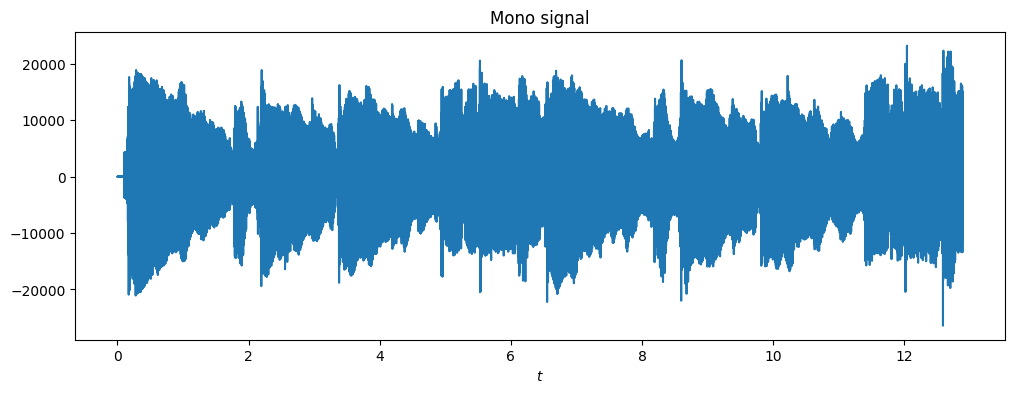

In [8]:
mono = sounddata@[1,1]

plt.figure(figsize=(12,4), dpi=100)
plt.plot(t, mono)
plt.xlabel(r'$t$')
plt.title('Mono signal')
plt.show()

Audio(mono, rate=framerate, autoplay=False)

<br>

___

<br>

_**(Problem 1)**_
The sample repeats the same riff twice. Crop the sample from $0 \le t \le 6.5$, and save it to a new time-series, $x^\text{cut}(t)$. Through Fourier analysis, you will be able to identify several dominant musical notes that appear in this part. What are they? List the five most dominant ones.

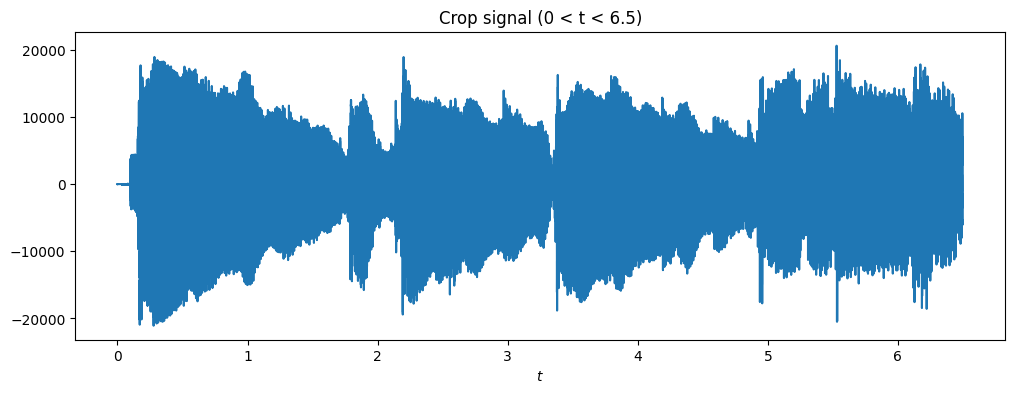

In [9]:
# your code here
t = np.arange(0,len(sounddata))/framerate
mono = sounddata@[1,1]

t_cut=t[t<=6.5]
x_cut=mono[t<=6.5]

plt.figure(figsize=(12,4), dpi=100)
plt.plot(t_cut, x_cut)
plt.xlabel(r'$t$')
plt.title('Crop signal (0 < t < 6.5)')
plt.show()

Audio(x_cut, rate=framerate, autoplay=False)

Five most dominant frequencies (Hz):
[85.69200874931536, 85.99969998360375, 86.15354560074795, 86.30739121789213, 861.3816103903353]


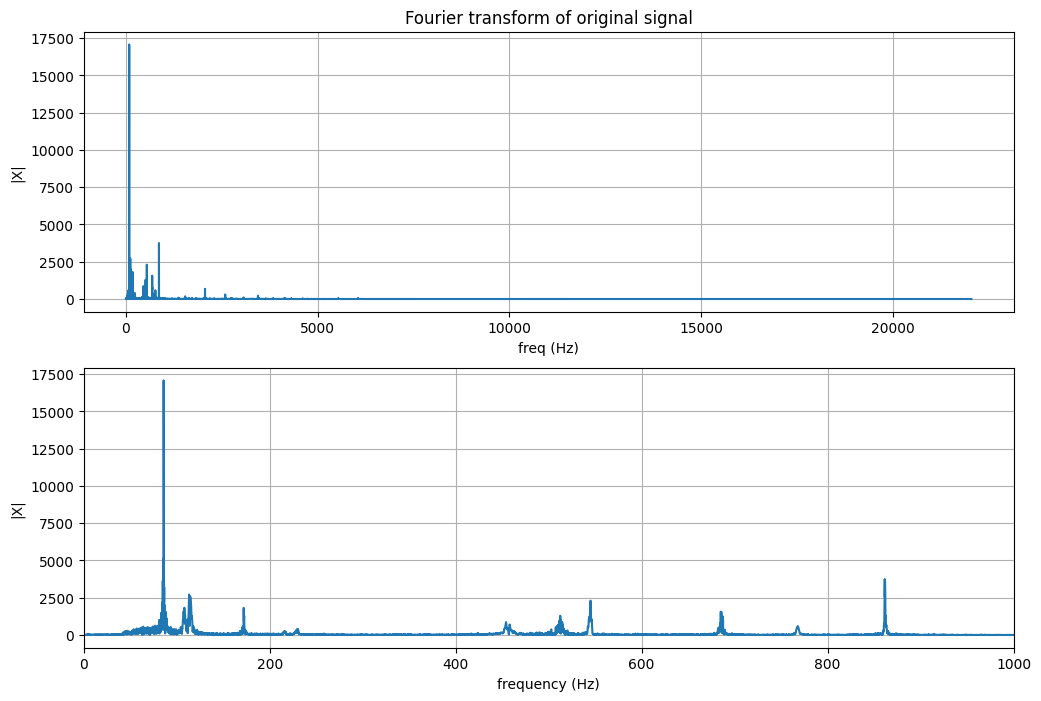

In [10]:
# your code here
N = len(x_cut)
df = framerate/N
f = np.arange(0,N)*df     # f = [0, df, 2*df,..., (N-1)*df]
dt=1/framerate
X = np.fft.fft(x_cut)*dt

freq=f[0:int(N/2+1)]
X_abs=np.abs(X)[0:int(N/2+1)]
peak=np.argsort(X_abs[1:])[-5:]+1
dom_freq=freq[peak]
dom_freq.sort()

print("Five most dominant frequencies (Hz):")
print(dom_freq.tolist())

plt.figure(figsize=(12,8), dpi=100)
plt.subplot(211)
plt.plot(freq,X_abs)
plt.xlabel('freq (Hz)')
plt.ylabel(r'|X|')
plt.title('Fourier transform of original signal')
plt.grid()

plt.subplot(212)
plt.plot(freq,X_abs)
plt.xlabel('frequency (Hz)')
plt.ylabel(r'|X|')
plt.grid()
plt.xlim(0,1000)

plt.show()

<br>

___

<br>

_**(Problem 2)**_
The sample includes performances from two instruments. Separate the performances of the two instruments based on $f_\text{threshold}=300\text{ Hz}$, saving the sounds heard in the range below $f_\text{threshold}$ in $x_\text{bass}$ and the sounds heard in the range above $f_\text{threshold}$ in $x_\text{guitar}$. Play both and check if the sounds of the two instruments are well-separated.

In [11]:
# your code here
def fft_threshold(x_cut,framerate,threshold):
    N = len(x_cut)  # 286651
    dt=1/framerate  # 1/44100
    X = np.fft.fft(x_cut)*dt    # 시간->주파수
    X_bass,X_guitar=X.copy(),X.copy()
    for i in range(1,N//2):
        current_freq=i*framerate/N
        if current_freq>threshold:
            X_bass[i]=0     # 1~N//2
            X_bass[N-i]=0   # 1+N//2~N-1 , 대칭성
        else:
            X_guitar[i]=0
            X_guitar[N-i]=0
    X_guitar[0]=0   #0
    x_bass=np.fft.ifft(X_bass).real*framerate   # 주파수->시간
    x_guitar=np.fft.ifft(X_guitar).real*framerate  # 주파수->시간
    return x_bass, x_guitar

x_cut=mono[t<=6.5]
framerate = data[0]
Audio(fft_threshold(x_cut,framerate,300)[0], rate=framerate, autoplay=False)


In [12]:
# your code here
Audio(fft_threshold(x_cut,framerate,300)[1], rate=framerate, autoplay=False)


<br>

___

<br>

_**(Problem 3)**_ Now your job is to make a software that receives a musical sound sample and generates sheet music for the sound. This can be achieved by performing Fourier analysis on moving windowed segments of the audio signals, and displaying the results as a two-dimensional frequency plot over time, as described below.

You can divide the audio data, $x^\text{cut}$ into segments of size `n_wdw` and create an array `fft_in` with intervals of size `n_itv` to perform the Fourier Transform.

The input matrix for the Fourier transform is defined as:

$$
\texttt{fft}_{\texttt{in}} 
= \begin{bmatrix} 
y^{(0)} & y^{(n_\text{itv})} & y^{(2n_\text{itv})} & \cdots & y^{(m n_\text{itv})} 
\end{bmatrix}
\in \mathbb{R}^{\,n_\text{wdw}\times(m+1)}
$$

where,

$$
\begin{aligned}
y^{(k)} &= 
\begin{bmatrix} 
x^\text{cut}_k & x^\text{cut}_{k+1} & \cdots & x^\text{cut}_{k+n_\text{wdw}-1} 
\end{bmatrix}^{T}
\in \mathbb{R}^{\,n_\text{wdw}} \\[6pt]
m &= \left\lfloor \frac{s - n_\text{wdw}}{n_\text{itv}} \right\rfloor
\end{aligned}
$$

Save the result into an array named `fft_out`.

<br>

<center>
<img src="https://jonghank.github.io/ase3001/files/itv_window.png" width="600">
</center>

In [14]:
# your code here
def fft_out(x,framerate,n_wdw,n_itv):   # STFT  방식 구현
    N=len(x)

    n_frames=(N-n_wdw)//n_itv + 1   # 시간 프레임
    STFT=np.zeros((n_wdw//2 + 1,n_frames),dtype=np.float64)  # 주파수, 시간 프레임
    window=np.hanning(n_wdw)   # 양끝 0; 윈도우 함수 적용하여 스펙트럼 누설 감소

    for i in range(n_frames):
        start=i*n_itv
        end=start+n_wdw
        chunk=x[start:end]  # 신호 조각
        if len(chunk)<n_wdw:
            pad=np.zeros(n_wdw,dtype=chunk.dtype)
            pad[:len(chunk)]=chunk
            chunk=pad
        chunk=chunk*window
        X_chunk=np.fft.rfft(chunk)
        STFT[:,i]=np.abs(X_chunk)/framerate

    # 주파수/시간 축
    freq=np.fft.rfftfreq(n_wdw, d=1.0/framerate)  # 실수 영역(양수 주파수 영역)
    time=np.arange(n_frames)*(n_itv/framerate)

    return STFT, freq, time

<br>

A spectogram is a plot of frequency intensities, which were obtained via Fourier analyses, over time. A Short-Time Fourier Transform (STFT) is used to create a spectogram. The STFT involves dividing the signal into fixed length segments (windows) and performing a Fourier transform on each segment to obtain the frequency at that time.

Plot a spectogram with your result saved in `fft_out` using `matplotlib.pyplot.pcolormesh`.

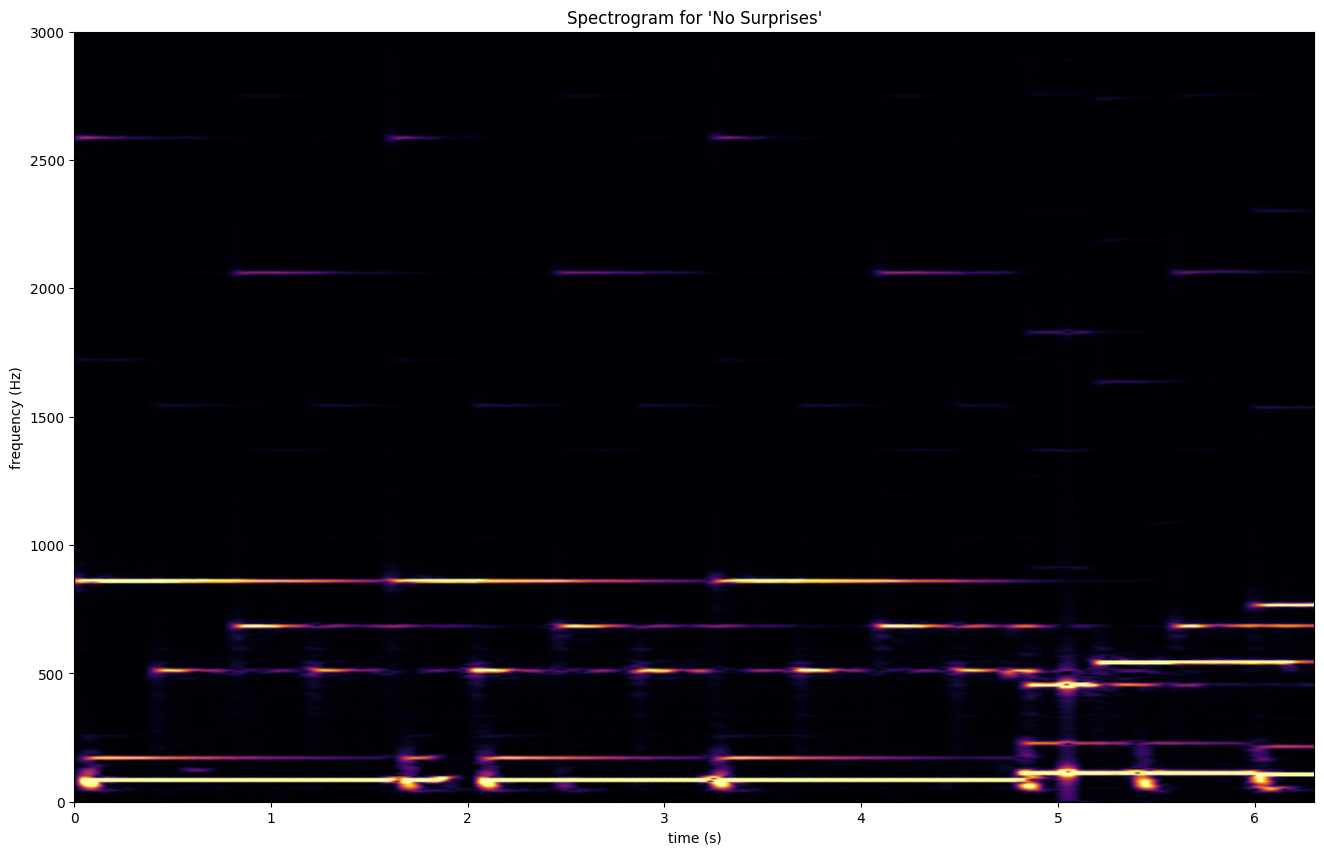

In [15]:
# your code here
n_wdw=2**(13)
n_itv=2**(9)
n_wdw,n_itv=int(n_wdw),int(n_itv)
stft_data,freq,time=fft_out(x_cut,framerate,n_wdw,n_itv)

plt.figure(figsize=(16,10))
plt.pcolormesh(time,freq,stft_data,cmap='inferno',shading='gouraud',vmin=0,vmax=100,antialiased=True)
plt.title("Spectrogram for 'No Surprises'")
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')
plt.ylim(0,3000)
plt.show()

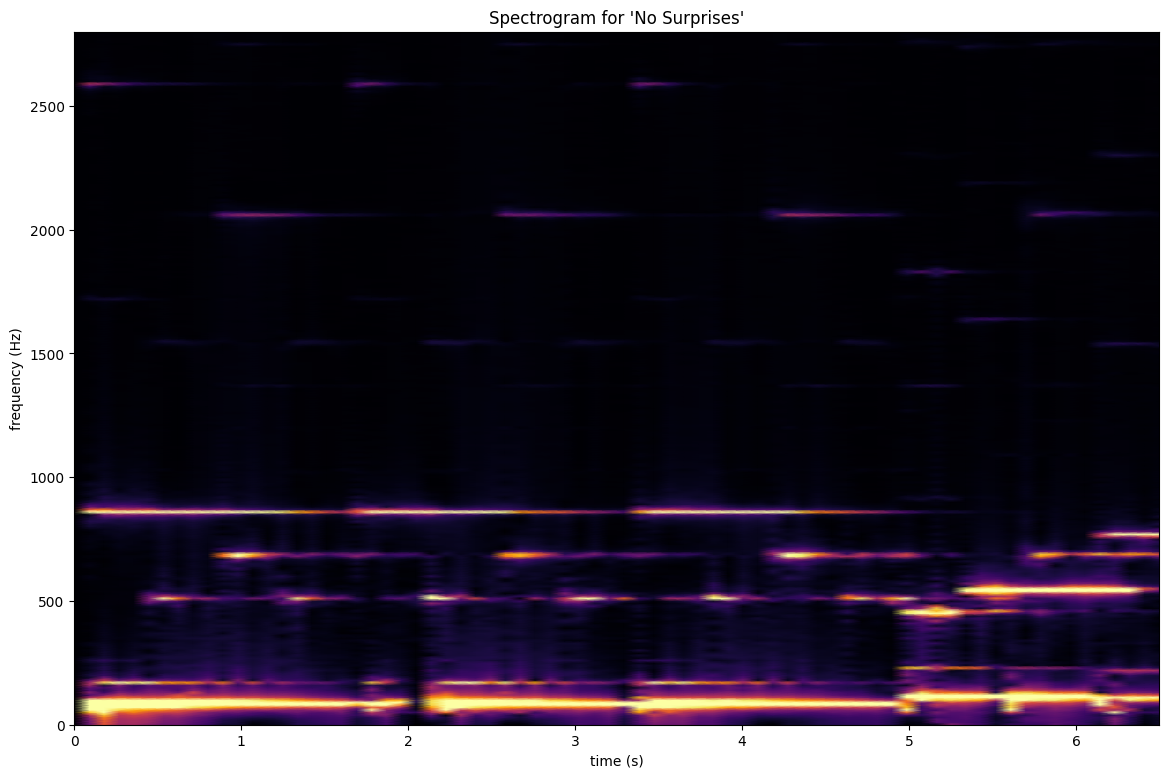

<br>

___

<br>

_**(Problem 4)**_
The piano key number N refers to a number defined to represent the keys on a standard piano keyboard, where key number 1 represents the leftmost key (A0) producing the lowest note on a standard 88-key piano, and key number 88 represents the rightmost key (C8), producing the highest note. A difference of one between key numbers corresponds to a half-step difference in pitch (see Piano key frequencies for reference). For example, key number 49 represents the middle A (A4) on the piano.

More specifically, the frequency of the note produced by a piano key number $N$ follows an exponential relationship as follows:

$$
f_N = 440\times 2^\frac{N-49}{12}.
$$

As $N$ increases, the note’s frequency rises exponentially. Each octave consists of 12 keys, corresponding to the 12 semitones in Western music. When you move up by one octave, the frequency of the note doubles. This shows the exponential increase in frequency as you move up the keyboard.

<br>

Overlay the frequencies corresponding to all the piano keys from key 37 up to 3 octaves (36 keys) on the spectrogram obtained earlier, and then identify the guitar notes that appear during the first 6.5 seconds of “No Surprises.” (Notice that Ed O'Brien, the band's rhythm guitarist who recorded this song, very slightly down-tuned his guitar.)

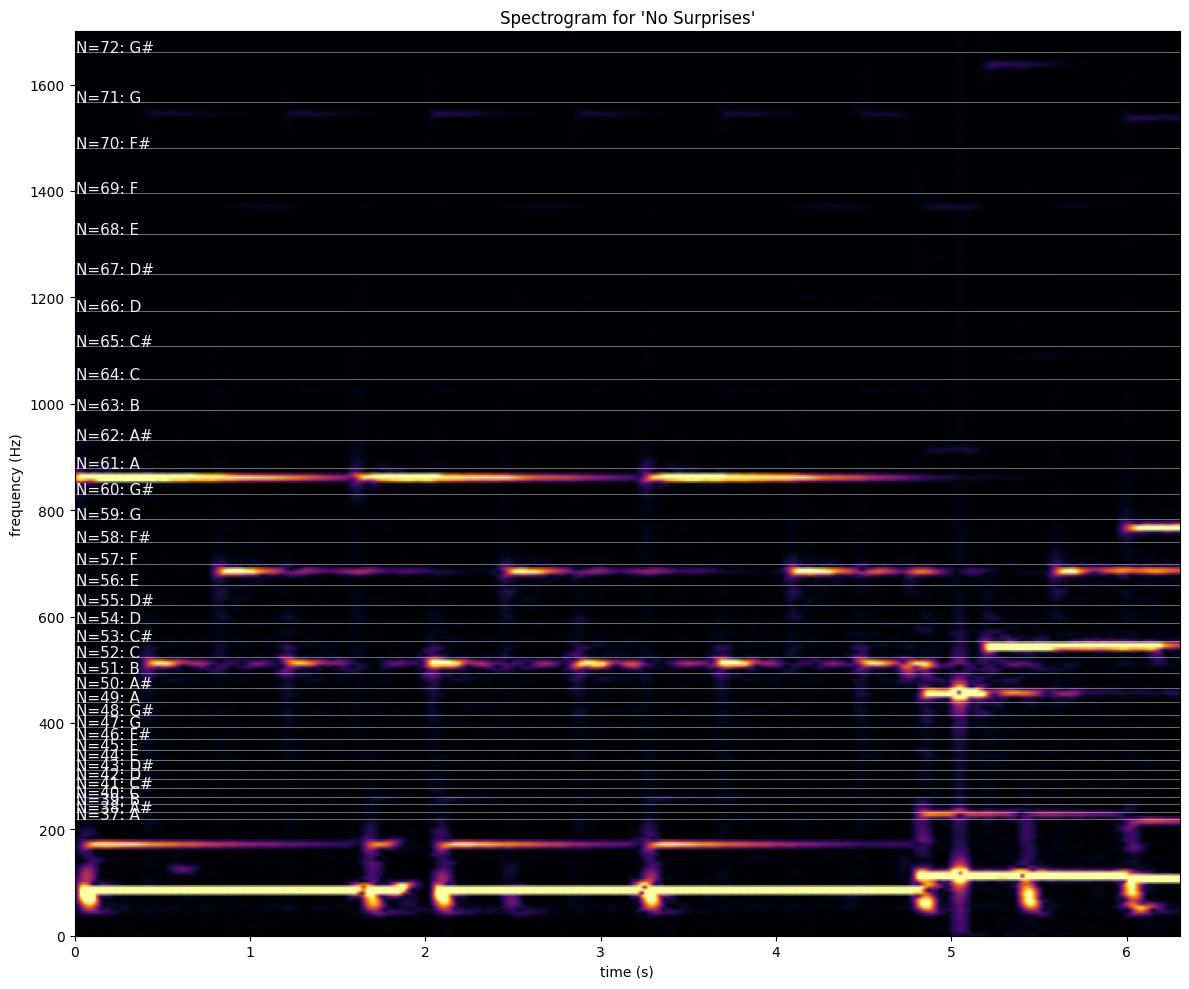

In [ ]:
# your code here
data = wavfile.read(r'C:\Users\변정우\OneDrive\Desktop\3학년\수치해석 프로젝트\5주차 과제\no_surprises_clip.wav')
#data = wavfile.read('/content/drive/MyDrive/Colab Notebooks/ase3001/no_surprises_clip.wav')
framerate = data[0]
sounddata = data[1]
mono = sounddata@[1,1]

start_key=37
num_keys=36
key_nums=np.arange(start_key,start_key+num_keys)    #[37,38,...,72]
key_freqs=440*2**((key_nums-49)/12)
note_names=['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']   # 12개
def key_to_note_name(k):
    return f"{note_names[(k+20)%12]}"
fig,ax=plt.subplots(figsize=(12,10))
im = ax.pcolormesh(time,freq,stft_data,cmap='inferno',shading='gouraud',vmin=0,vmax=100)    #STFT 결과
ax.set_title("Spectrogram for 'No Surprises'")
ax.set_xlabel("time (s)")
ax.set_ylabel("frequency (Hz)")
ax.set_ylim(0,1700)
for k, f0 in zip(key_nums,key_freqs):   # k -> [37,38,...,72] , f0 -> [220, 233, ..., 1661]
    ax.axhline(f0, color='white',linewidth=0.6,alpha=0.5)
    # 좌측으로부터 0.01만큼 떨어트리고 작성
    ax.text(0.01, f0, f"N={k}: {key_to_note_name(k)}",color='white',fontsize=11,alpha=0.95)
plt.tight_layout()
plt.show()

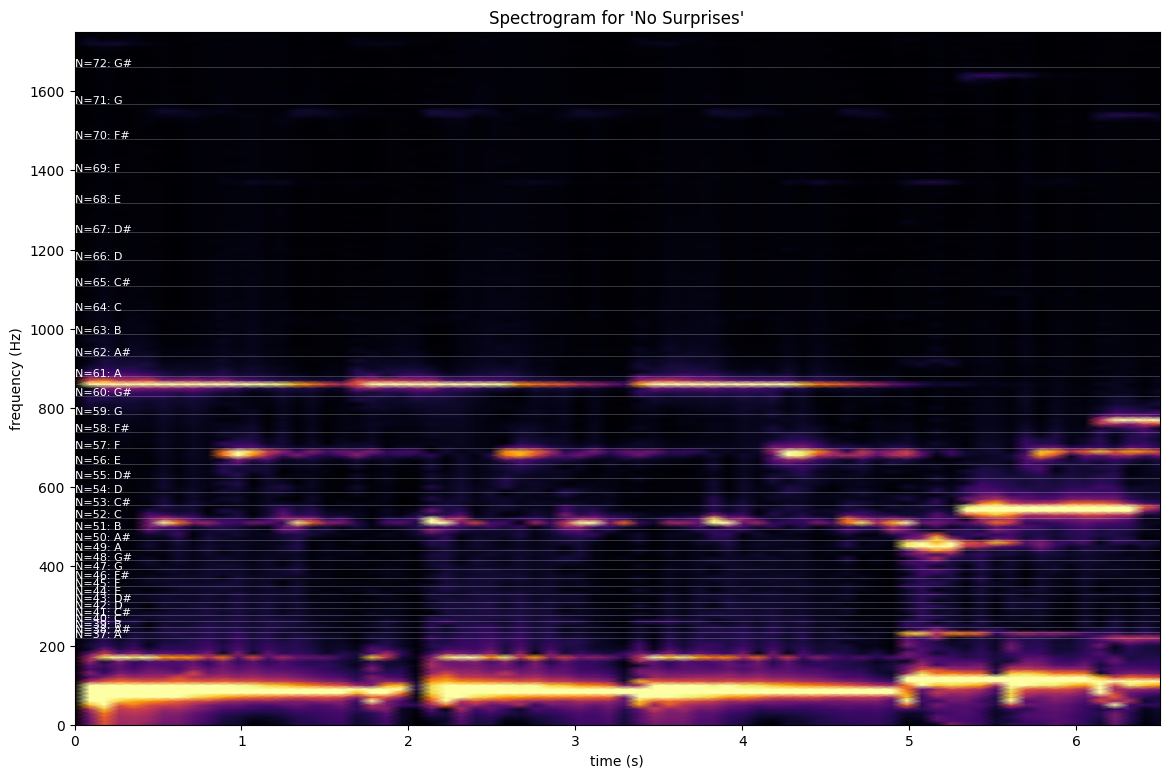

<br>

___

<br>

_**(Problem 5)**_
Create a new audio file from the provided No Surprises recording by raising every pitch by _4 semitones (2 whole steps)_, while preserving the total playback duration exactly as in the original. Your program should load the audio using its original sampling rate (do not resample), apply pitch shifting, and if the resulting signal is shorter or longer in sample count, pad with silence or trim the ends so that the sample length matches the original exactly. The output file might be named no_surprises_key+4.wav (or a similarly clear name).

In addition, your code should print or otherwise verify that the sample rate, total number of samples (or duration in seconds), and the number of channels of the output match those of the original input. Optionally, you may include a small waveform or spectrum comparison to illustrate the pitch shift. The key aim is: pitch is altered, but timing (length) is unchanged.

In [22]:
semitones_shift=4
sounddata_float=sounddata.astype(np.float32)  # 음성 데이터를 float32로 변환하여 처리
num_samples = sounddata.shape[0]
channels = sounddata.shape[1]

# +4 세미톤에 대응하는 배수(factor)와 시간 비율(rate) 계산
factor=2**(semitones_shift/12)
rate=1/factor   # STFT 시간축을 이 비율로 재샘플링
n_fft=2**11
hop_length=n_fft//4  # overlap=1-(n_fft//4)/n_fft -> 75퍼

def phase_vocoder(Z,rate):   # STFT Z 행렬을 시간축 비율로 늘려서 조정
    n_freqs,n_frames=Z.shape    # 주파수 구간 * 시간 프레임
    time_steps=np.arange(0,n_frames,rate)
    output=np.zeros((n_freqs,len(time_steps)),dtype=np.complex64)
    phi=np.angle(Z[:,0]).copy()  # 주파수 구간의 초기 위상 저장
    for idx, step in enumerate(time_steps):
        int_step=int(np.floor(step))
        frac=step-int_step  # 위상 유지 작업
        if int_step+1>=n_frames:
            break
        D0,D1=Z[:,int_step],Z[:,int_step+1]     # 보간 요소
        mag=(1-frac)*np.abs(D0)+frac*np.abs(D1)   # 두 프레임 보간
        phase_0,phase_1=np.angle(D0),np.angle(D1)
        delta_phi=phase_1-phase_0
        delta_phi-=2*np.pi*np.round((delta_phi)/(2*np.pi))
        phi+=delta_phi  # 위상 누적
        output[:,idx]=mag*np.exp(1j*phi)
    return output

# 각 채널에 대해 STFT→phase vocoder→ISTFT→리샘플을 수행
from scipy.signal import stft, istft, resample
shifted_channels=[]
for ch in range(channels):
    y=sounddata_float[:, ch] if channels > 1 else sounddata_float
    f,t,Z=stft(y,fs=framerate,nperseg=n_fft,noverlap=n_fft-hop_length)    # STFT
    Z_stretch=phase_vocoder(Z,rate)    # phase vocoder(time stretch) 
    t_stretch,y_stretch=istft(Z_stretch,fs=framerate,nperseg=n_fft,noverlap=n_fft-hop_length)    # ISTFT
    y_shifted=resample(y_stretch,num_samples)    # 리샘플링
    shifted_channels.append(y_shifted)
shifted_audio=np.stack(shifted_channels,axis=1)

shifted_norm=shifted_audio/np.max(np.abs(shifted_audio))
dtype_info=np.iinfo(sounddata.dtype)
shifted_int=(shifted_norm*dtype_info.max).astype(sounddata.dtype)

output_path="no_surprises_key+4_manual_stft.wav"
from scipy.io import wavfile
wavfile.write(output_path,framerate,shifted_int)

print(f"Original sample rate: {framerate}")
print(f"Shifted sample rate: {framerate}")
print(f"Original number of samples: {num_samples}")
print(f"Shifted number of samples: {shifted_int.shape[0]}")
print(f"Original duration (seconds): {num_samples/framerate}")
print(f"Shifted duration (seconds): {shifted_int.shape[0]/framerate}")
print(f"Original number of channels: {channels}")
print(f"Shifted number of channels: {shifted_int.shape[1]}")
print(f"New audio file saved as {output_path}")

pitchup_audio=(shifted_int[:, 0]).astype(np.float32) / dtype_info.max
Audio(pitchup_audio, rate=framerate, autoplay=False)


Original sample rate: 44100
Shifted sample rate: 44100
Original number of samples: 568681
Shifted number of samples: 568681
Original duration (seconds): 12.895260770975057
Shifted duration (seconds): 12.895260770975057
Original number of channels: 2
Shifted number of channels: 2
New audio file saved as no_surprises_key+4_manual_stft.wav


Original sample rate: 44100  
Shifted sample rate: 44100  
Original number of samples: 568681  
Shifted number of samples: 568681  
Original duration (seconds): 12.895260770975057  
Shifted duration (seconds): 12.895260770975057  
Original number of channels: 2  
Shifted number of channels: 2  
New audio file saved as no_surprises_key+4_manual_stft.wav  